# Test synthetic data function

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from modules.create_data import create_stroke_data

In [2]:
df = create_stroke_data(n=10000, seed=42)
df

,patient_id,year,age,ethnicity,male,warfarin,shoe_size,nihss,thrombolysis_time,thrombolysis,...,mortality_odds_no_treatment,mortality_log_odds_no_treatment,mortality_prob_treated,mortality_odds_treated,mortality_log_odds_treated,odds_ratio_treated,log_odds_ratio_treated,probability_difference,mortality_probability,died
0,1,2024,66,white,1,0,5,6,145.0,1,...,0.2346,-1.4500,0.0662,0.0709,-2.6467,3.3091,1.1967,0.1238,0.0662,0
1,2,2023,79,white,1,0,7,13,99999.0,0,...,0.4815,-0.7309,0.3250,0.4815,-0.7309,1.0000,0.0000,0.0000,0.3250,0
2,3,2021,88,white,1,0,8,7,301.0,1,...,0.4493,-0.8001,0.2450,0.3246,-1.1253,1.3843,0.3252,0.0650,0.2450,1
3,4,2020,74,white,0,0,9,11,99999.0,0,...,0.4925,-0.7082,0.3300,0.4925,-0.7082,1.0000,0.0000,0.0000,0.3300,0
4,5,2024,70,black,1,0,12,23,99999.0,0,...,0.9231,-0.0800,0.4800,0.9231,-0.0800,1.0000,0.0000,-0.0000,0.4800,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,2023,84,white,1,0,11,15,99999.0,0,...,0.5873,-0.5322,0.3700,0.5873,-0.5322,1.0000,0.0000,0.0000,0.3700,0
9996,9997,2022,87,asian,0,0,10,2,99999.0,0,...,0.3423,-1.0721,0.2550,0.3423,-1.0721,1.0000,0.0000,-0.0000,0.2550,1
9997,9998,2018,64,white,0,0,10,22,99999.0,0,...,0.4085,-0.8954,0.2900,0.4085,-0.8954,1.0000,0.0000,0.0000,0.2900,0
9998,9999,2023,83,white,0,0,10,14,140.0,1,...,0.4388,-0.8236,0.1146,0.1295,-2.0442,3.3894,1.2206,0.1904,0.1146,0


In [3]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
patient_id,10000.0,5000.500,2886.896,1.000,2500.750,5000.500,7500.250,10000.000
year,10000.0,2020.981,1.986,2018.000,2019.000,2021.000,2023.000,2024.000
age,10000.0,74.728,8.656,60.000,67.000,75.000,82.000,89.000
male,10000.0,0.516,0.500,0.000,0.000,1.000,1.000,1.000
warfarin,10000.0,0.194,0.396,0.000,0.000,0.000,0.000,1.000
shoe_size,10000.0,8.500,1.666,5.000,7.000,8.000,10.000,12.000
nihss,10000.0,12.842,6.210,0.000,8.000,12.000,17.000,29.000
thrombolysis_time,10000.0,70106.672,45718.018,30.000,305.000,99999.000,99999.000,99999.000
thrombolysis,10000.0,0.300,0.458,0.000,0.000,0.000,1.000,1.000
mortality_prob_no_treatment,10000.0,0.312,0.092,0.065,0.245,0.310,0.370,0.695


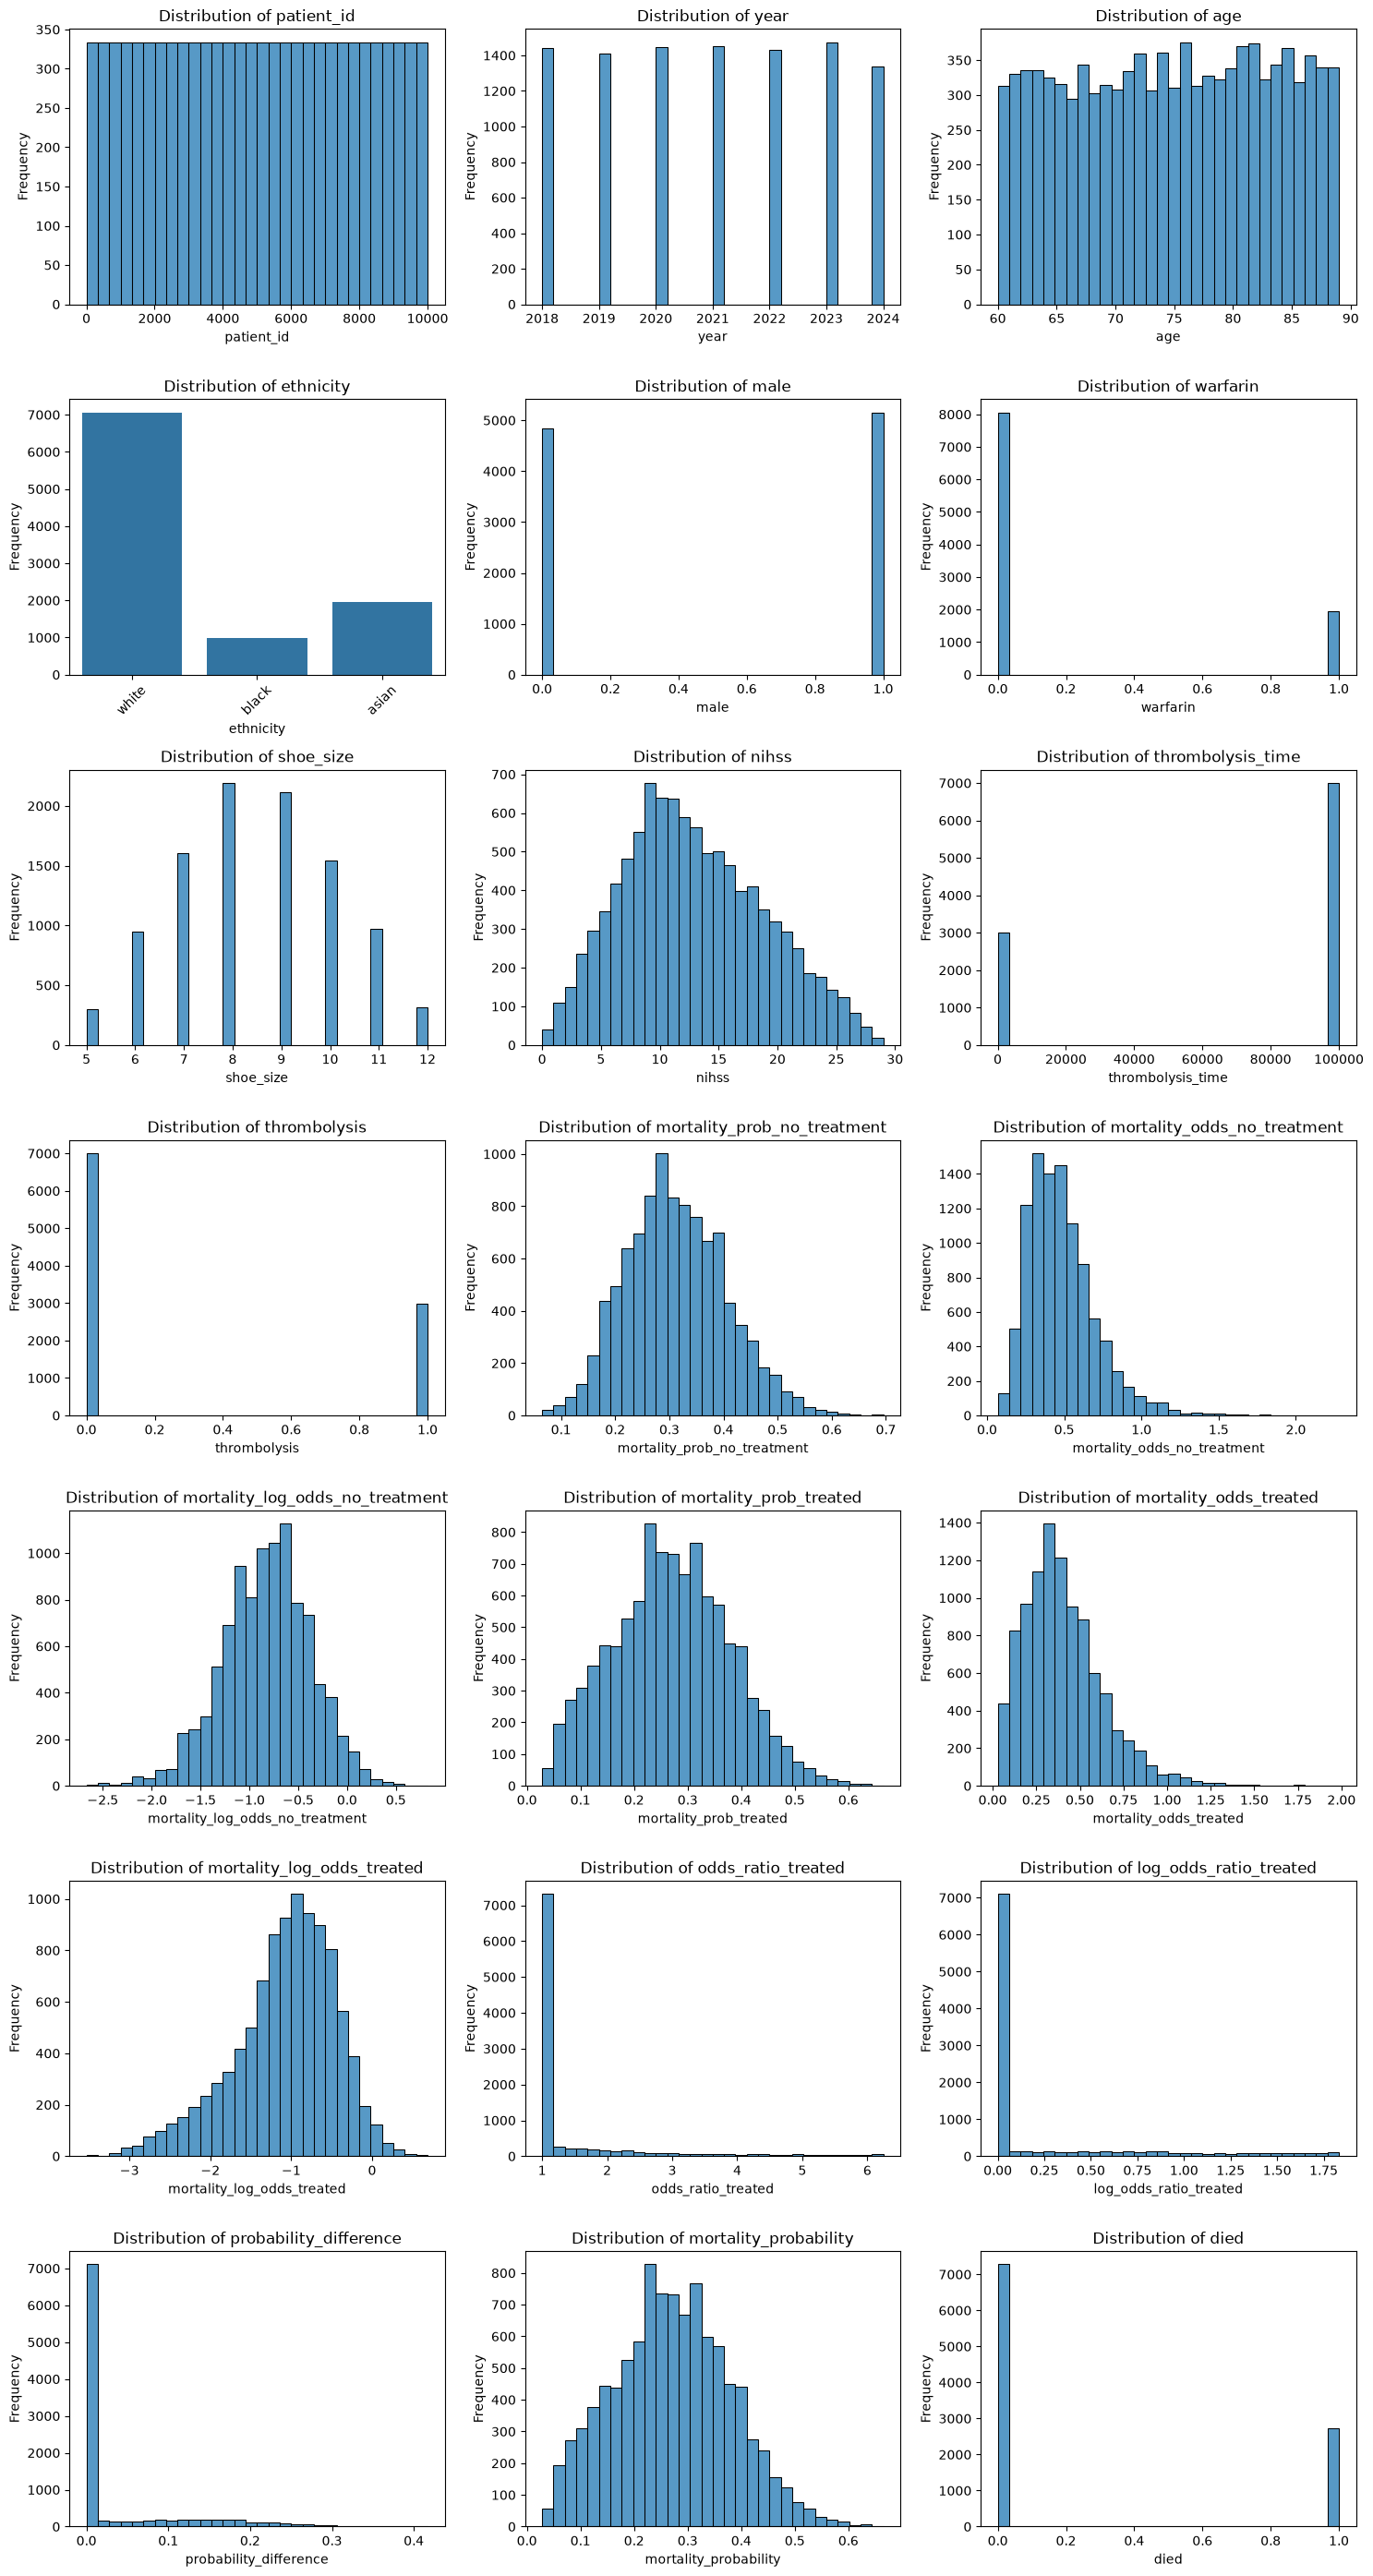

In [4]:
import math

# Plot the distributions of all the variables in the dataset

ncols = 3
nrows = math.ceil(len(df.columns) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.ravel()

for ax, col in zip(axes, df.columns):
    if pd.api.types.is_numeric_dtype(df[col]):
        sns.histplot(data=df, x=col, kde=False, bins=30, ax=ax)
    else:
        sns.countplot(data=df, x=col, ax=ax)
        ax.tick_params(axis="x", rotation=45)

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for ax in axes[len(df.columns):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()